In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("EDA environment ready")

EDA environment ready


In [ ]:
# 🎓 Student Dropout Prediction — Exploratory Data Analysis

## 🎯 Objective

This notebook explores the Student Dropout dataset to understand its structure, data quality, feature distributions, missing values, and relationships between student characteristics and the `Dropout` target.

### Target Variable

- `0` — Student Retained
- `1` — Student Dropped Out

### EDA Goals

1. Understand the dataset structure
2. Identify missing values and data-quality issues
3. Examine the target class distribution
4. Analyze numerical and categorical features
5. Investigate relationships with student dropout
6. Identify insights that can guide preprocessing and model development

In [ ]:
## 📥 1. Load and Inspect the Dataset

In [3]:
from pathlib import Path

DATA_PATH = Path("../data/raw/student_dropout_dataset_v3.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 10,000
Columns: 19


In [4]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  str    
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  str    
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  str    
 10  Scholarship            10000 non-null  str    
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Semester      

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Student_ID,10000.0,5000.500000,2886.895680,1.0,2500.75,5000.50,7500.25,10000.00
Age,10000.0,21.026060,2.139810,17.0,19.50,21.00,22.50,29.60
Family_Income,9500.0,38377.247474,20496.232179,25000.0,25000.00,29740.50,44520.00,316601.00
Study_Hours_per_Day,9500.0,4.014592,1.295450,0.5,3.16,4.00,4.87,8.98
Attendance_Rate,10000.0,81.736830,8.220930,38.2,76.40,81.80,87.30,100.00
Assignment_Delay_Days,10000.0,1.799700,1.344307,0.0,1.00,2.00,3.00,8.00
Travel_Time_Minutes,10000.0,30.179260,11.918870,5.0,21.90,30.20,38.40,74.90
Stress_Index,9500.0,5.507147,1.765951,1.0,4.30,5.50,6.70,10.00
GPA,10000.0,2.308440,1.061717,0.0,1.55,2.35,3.12,4.00
Semester_GPA,10000.0,2.300057,1.074407,0.0,1.52,2.35,3.15,4.00


In [ ]:
## 🔍 2. Data Quality Analysis

Before preprocessing, we examine missing values, duplicate records, identifiers, data types, and potential data-quality issues.

In [7]:
# Missing-value analysis
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean() * 100).round(2)
})

missing[missing["Missing_Count"] > 0].sort_values(
    "Missing_Count",
    ascending=False
)

,Missing_Count,Missing_Percentage
Parental_Education,511,5.11
Family_Income,500,5.00
Study_Hours_per_Day,500,5.00
Stress_Index,500,5.00


In [8]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Student IDs: {df['Student_ID'].duplicated().sum()}")
print(f"Unique Student IDs: {df['Student_ID'].nunique():,}")

Duplicate rows: 0
Duplicate Student IDs: 0
Unique Student IDs: 10,000


In [9]:
print("Target values:", sorted(df["Dropout"].unique()))
print("\nCategorical columns:")

for column in df.select_dtypes(include=["object", "string"]).columns:
    print(f"{column}: {df[column].unique()}")

Target values: [np.int64(0), np.int64(1)]

Categorical columns:
Gender: <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
Internet_Access: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Part_Time_Job: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Scholarship: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Semester: <ArrowStringArray>
['Year 1', 'Year 3', 'Year 4', 'Year 2']
Length: 4, dtype: str
Department: <ArrowStringArray>
['Arts', 'Engineering', 'CS', 'Business', 'Science']
Length: 5, dtype: str
Parental_Education: <ArrowStringArray>
['High School', 'Bachelor', 'Master', nan, 'PhD']
Length: 5, dtype: str


In [ ]:
## 🎯 3. Target Variable Analysis

The target variable, `Dropout`, indicates whether a student remained enrolled or dropped out:

- `0` — Retained
- `1` — Dropped Out

We examine the class distribution to determine whether class imbalance should be considered during model evaluation.

In [10]:
target_counts = df["Dropout"].value_counts().sort_index()
target_percentages = (
    df["Dropout"].value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_summary.index = ["Retained (0)", "Dropped Out (1)"]
target_summary

,Count,Percentage
Retained (0),7646,76.46
Dropped Out (1),2354,23.54


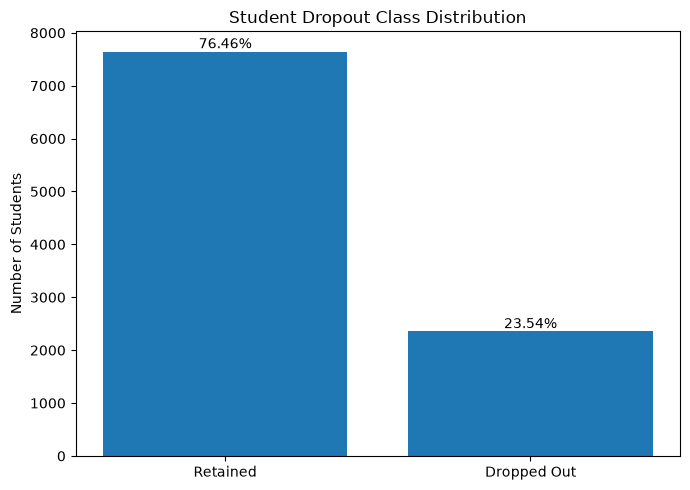

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["Retained", "Dropped Out"],
    target_counts.values
)

ax.set_title("Student Dropout Class Distribution")
ax.set_ylabel("Number of Students")

for bar, percentage in zip(bars, target_percentages.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 📊 4. Numerical Feature Analysis

This section examines the distributions of numerical features and compares their patterns across retained and dropout students.

In [12]:
numerical_features = [
    "Age",
    "Family_Income",
    "Study_Hours_per_Day",
    "Attendance_Rate",
    "Assignment_Delay_Days",
    "Travel_Time_Minutes",
    "Stress_Index",
    "GPA",
    "Semester_GPA",
    "CGPA"
]

df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,21.026060,2.139810,17.0,19.50,21.00,22.50,29.60
Family_Income,9500.0,38377.247474,20496.232179,25000.0,25000.00,29740.50,44520.00,316601.00
Study_Hours_per_Day,9500.0,4.014592,1.295450,0.5,3.16,4.00,4.87,8.98
Attendance_Rate,10000.0,81.736830,8.220930,38.2,76.40,81.80,87.30,100.00
Assignment_Delay_Days,10000.0,1.799700,1.344307,0.0,1.00,2.00,3.00,8.00
Travel_Time_Minutes,10000.0,30.179260,11.918870,5.0,21.90,30.20,38.40,74.90
Stress_Index,9500.0,5.507147,1.765951,1.0,4.30,5.50,6.70,10.00
GPA,10000.0,2.308440,1.061717,0.0,1.55,2.35,3.12,4.00
Semester_GPA,10000.0,2.300057,1.074407,0.0,1.52,2.35,3.15,4.00
CGPA,10000.0,2.298761,1.072555,0.0,1.52,2.35,3.15,4.00


In [13]:
dropout_comparison = (
    df.groupby("Dropout")[numerical_features]
      .mean()
      .T
)

dropout_comparison.columns = ["Retained", "Dropped_Out"]
dropout_comparison["Difference"] = (
    dropout_comparison["Dropped_Out"] -
    dropout_comparison["Retained"]
)

dropout_comparison.round(2)

,Retained,Dropped_Out,Difference
Age,21.02,21.06,0.04
Family_Income,38503.91,37966.97,-536.93
Study_Hours_per_Day,4.08,3.81,-0.27
Attendance_Rate,82.48,79.31,-3.17
Assignment_Delay_Days,1.74,2.00,0.26
Travel_Time_Minutes,29.99,30.78,0.79
Stress_Index,5.26,6.32,1.06
GPA,2.58,1.43,-1.15
Semester_GPA,2.57,1.44,-1.13
CGPA,2.56,1.44,-1.12


In [14]:
dropout_comparison.round(2)

,Retained,Dropped_Out,Difference
Age,21.02,21.06,0.04
Family_Income,38503.91,37966.97,-536.93
Study_Hours_per_Day,4.08,3.81,-0.27
Attendance_Rate,82.48,79.31,-3.17
Assignment_Delay_Days,1.74,2.00,0.26
Travel_Time_Minutes,29.99,30.78,0.79
Stress_Index,5.26,6.32,1.06
GPA,2.58,1.43,-1.15
Semester_GPA,2.57,1.44,-1.13
CGPA,2.56,1.44,-1.12


In [ ]:
## 📈 5. Numerical Features vs Dropout

This section compares selected academic and behavioral characteristics between retained and dropout students to identify potentially useful predictive patterns.

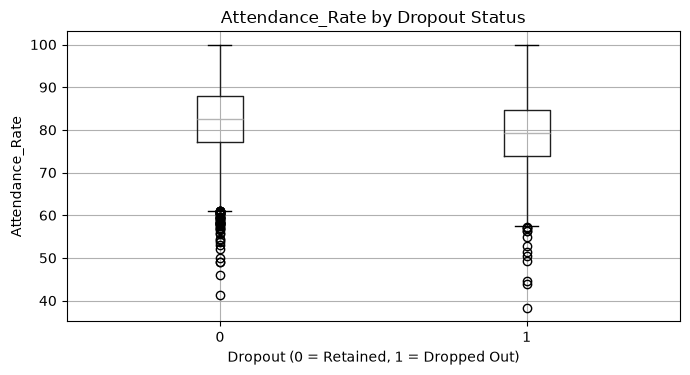

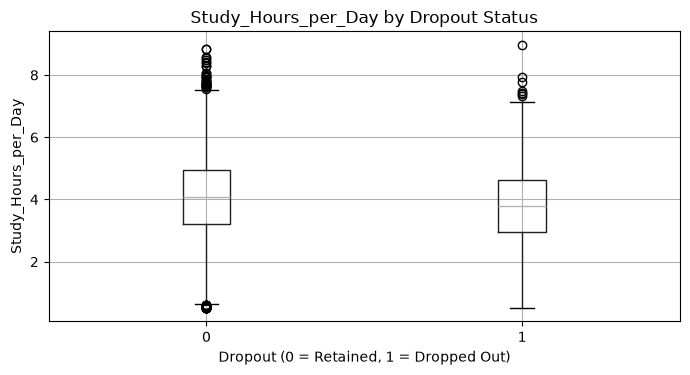

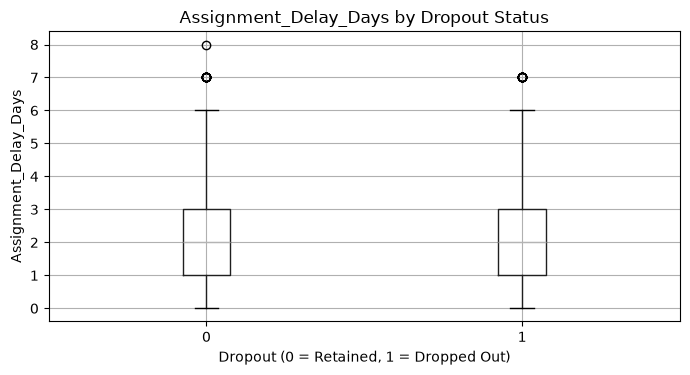

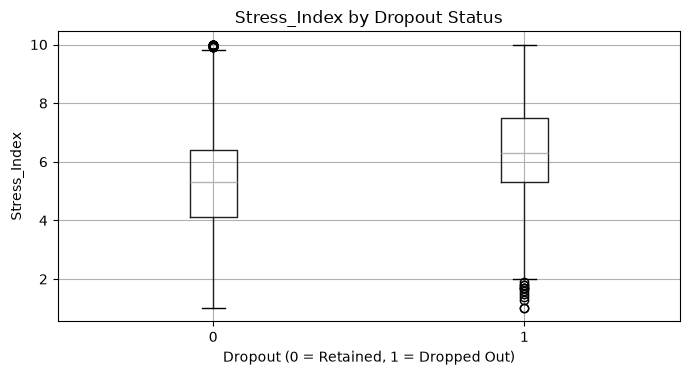

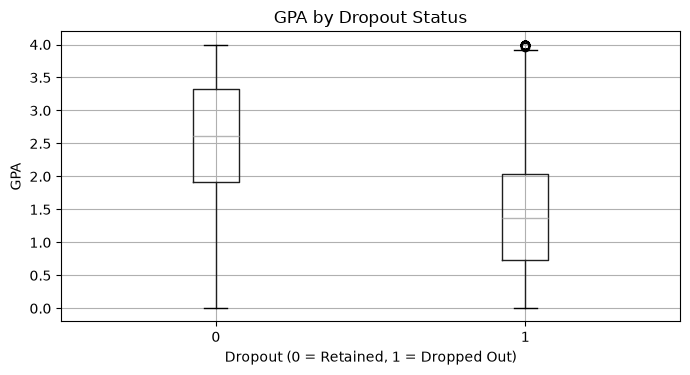

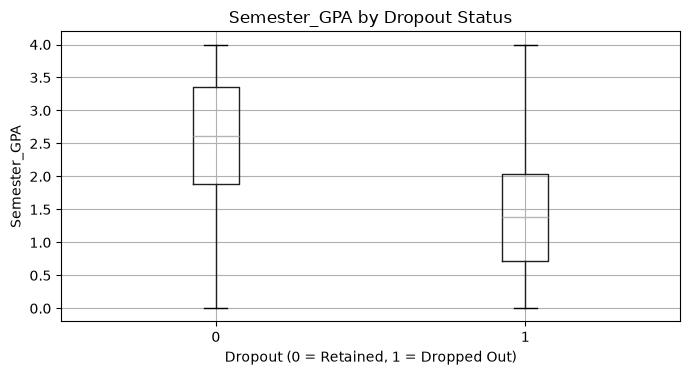

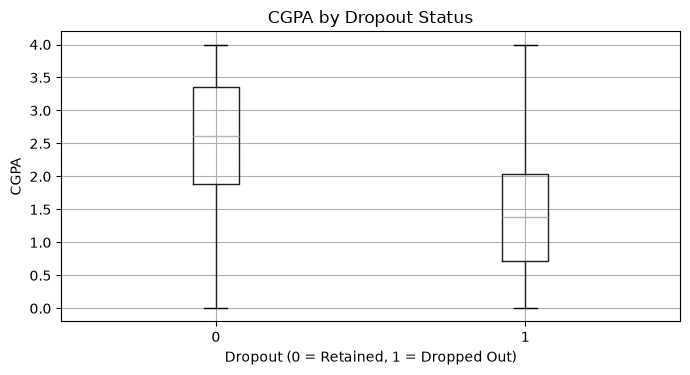

In [15]:
important_features = [
    "Attendance_Rate",
    "Study_Hours_per_Day",
    "Assignment_Delay_Days",
    "Stress_Index",
    "GPA",
    "Semester_GPA",
    "CGPA"
]

for feature in important_features:
    df.boxplot(
        column=feature,
        by="Dropout",
        figsize=(7, 4)
    )

    plt.title(f"{feature} by Dropout Status")
    plt.suptitle("")
    plt.xlabel("Dropout (0 = Retained, 1 = Dropped Out)")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

In [16]:
df.groupby("Dropout")[important_features].median().T.round(2)

Dropout,0,1
Attendance_Rate,82.60,79.30
Study_Hours_per_Day,4.08,3.80
Assignment_Delay_Days,2.00,2.00
Stress_Index,5.30,6.30
GPA,2.62,1.37
Semester_GPA,2.62,1.39
CGPA,2.62,1.38


In [ ]:
## 🏷️ 6. Categorical Features vs Dropout

This section examines dropout rates across categorical student characteristics to identify patterns that may contribute useful predictive information.

In [17]:
## 🏷️ 6. Categorical Features vs Dropout

This section examines dropout rates across categorical student characteristics to identify patterns that may contribute useful predictive information.


--- Gender ---


,Students,Dropout_Rate
Gender,,
Female,5011,23.85
Male,4989,23.23



--- Internet_Access ---


,Students,Dropout_Rate
Internet_Access,,
No,1231,28.43
Yes,8769,22.85



--- Part_Time_Job ---


...

,Students,Dropout_Rate
Semester,,
Year 1,2455,22.16
Year 2,2488,24.40
Year 3,2521,23.88
Year 4,2536,23.70



--- Department ---


,Students,Dropout_Rate
Department,,
Arts,2026,23.94
Business,2002,23.33
CS,1974,23.40
Engineering,1937,24.01
Science,2061,23.05



--- Parental_Education ---


,Students,Dropout_Rate
Parental_Education,,
Bachelor,3949,23.22
High School,3072,24.61
Master,2003,22.12
PhD,465,23.66
NaN,511,25.05


In [18]:
df.groupby("Scholarship")["Dropout"].agg(
    Students="count",
    Dropout_Rate="mean"
).assign(
    Dropout_Rate=lambda x: (x["Dropout_Rate"] * 100).round(2)
)

,Students,Dropout_Rate
Scholarship,,
No,6489,23.75
Yes,3511,23.16


In [ ]:
## 🔗 7. Correlation Analysis

This section examines correlations among numerical features and their relationships with the dropout target. Correlation is used as an exploratory tool and does not imply causation.

In [19]:
correlation_columns = numerical_features + ["Dropout"]

correlation_matrix = df[correlation_columns].corr()

dropout_correlations = (
    correlation_matrix["Dropout"]
    .drop("Dropout")
    .sort_values(key=abs, ascending=False)
)

dropout_correlations.round(3)

GPA                     -0.460
Semester_GPA            -0.445
CGPA                    -0.445
Stress_Index             0.256
Attendance_Rate         -0.164
Study_Hours_per_Day     -0.089
Assignment_Delay_Days    0.082
Travel_Time_Minutes      0.028
Family_Income           -0.011
Age                      0.008
Name: Dropout, dtype: float64

In [ ]:
## 📝 8. EDA Summary & Key Findings

The exploratory analysis identified several important characteristics of the Student Dropout dataset:

### Data Quality
- The dataset contains 10,000 student records and 19 columns.
- No duplicate records were identified.
- Missing values are present in `Family_Income`, `Study_Hours_per_Day`, `Stress_Index`, and `Parental_Education`.
- `Student_ID` is an identifier and should be excluded from predictive modeling.

### Target Distribution
- 76.46% of students are retained.
- 23.54% of students dropped out.
- The target therefore exhibits class imbalance, which should be considered during model evaluation.

### Numerical Relationships
The strongest observed numerical correlations with dropout were:

- GPA: -0.460
- Semester GPA: -0.445
- CGPA: -0.445
- Stress Index: +0.256
- Attendance Rate: -0.164

Higher academic performance and attendance were associated with lower dropout, while higher stress was associated with increased dropout.

### Categorical Observations
- Students without internet access showed a higher dropout rate (28.43%) than students with internet access (22.85%).
- Scholarship status showed only a small difference in dropout rate.
- Dropout rates were relatively similar across departments.

### Modeling Implications
The preprocessing and modeling stage should:

1. Exclude `Student_ID` from predictive features.
2. Handle missing numerical and categorical values systematically.
3. Encode categorical variables appropriately.
4. Preserve the train/test separation during preprocessing to prevent data leakage.
5. Account for class imbalance during evaluation.
6. Compare multiple classification models using more than accuracy alone.